
# Inversion with structural constraints

Any inversion suffers from ambiguity and missing resolution at depth.
Structural information can provide valuable information about geological
boundaries in the subsurface. Such information can come from wave methods
like seismics (Tanner et al. 2020), ground-penetrating radar (Doetsch et
al. 2012, Jiang et al. 2020) or even piece-wise from boreholes (Wunderlich
et al. 2018). This can be done in both 2D (Jiang et al. 2020) using lines
or in 3D using facets (Doetsch et al. 2012).

We demonstrate on a very simple example from a bedrock detection how
a structural interface from a seismic refraction can lead to models that
are far easier to interpret.


In [1]:
%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

First we load the data and the interface

In [3]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line09/constraints", exist_ok=True)

filename = r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas\data\line09\Line09_DD_wTOPO_comsor_constraints.dat'
data = ert.load(filename)
print(data)

10/02/26 - 13:57:14 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 108 data: 3827, nonzero entries: ['a', 'b', 'm', 'n', 'rhoa', 'valid']


In [4]:
xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line

data_min = xs.min(); data_max = xs.max()

print(data_min, data_max)

0.0 1070.0


In [5]:
topo = []
start_topo = False

with open(filename) as f: 
    for line in f:
        line = line.strip()
        if "Topography in a separate list" in line:
            start_topo = True; continue
        if start_topo:
            parts = line.split()  # split using whitespace
            if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
                topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))


# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

Now we will make a graph!! And show the data woohoo

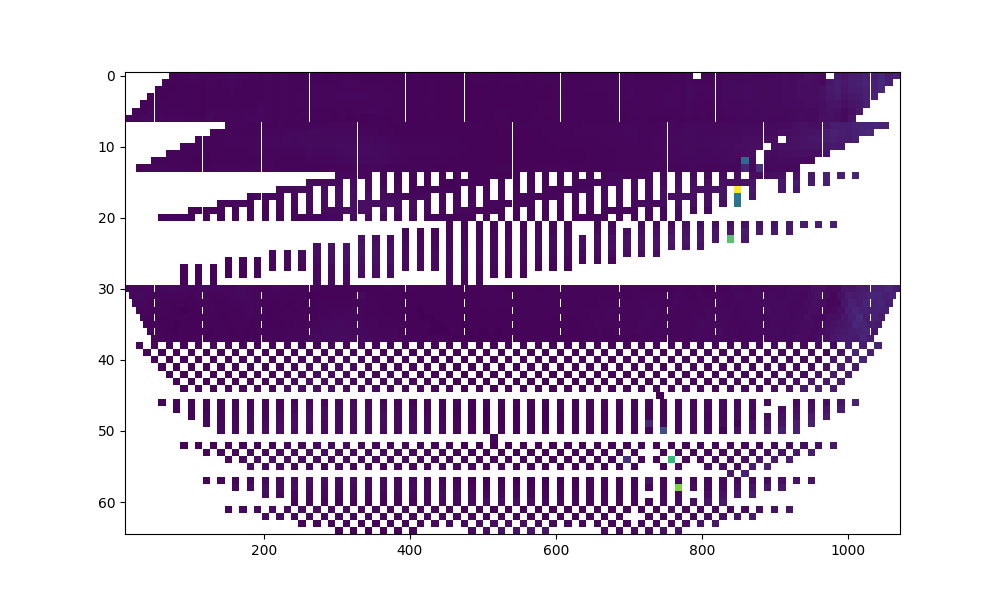

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

_ = ert.showData(data,
                ax=ax,
                ylabel='Pseudo depth [m]', xlabel='Distance [m]',
                logScale=True,
)

ax.set_title('ERT Data with Apparent Resistivity');

We estimate an error and do a normal inversion using the ERT manager.
As we expect more or less layered structures, we choose a vertical
weighting factor for the regularization of 0.5.




10/02/26 - 13:57:25 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 1): C:\Users\sydne\AppData\Roaming\pygimli\Cache\13641336607832227461


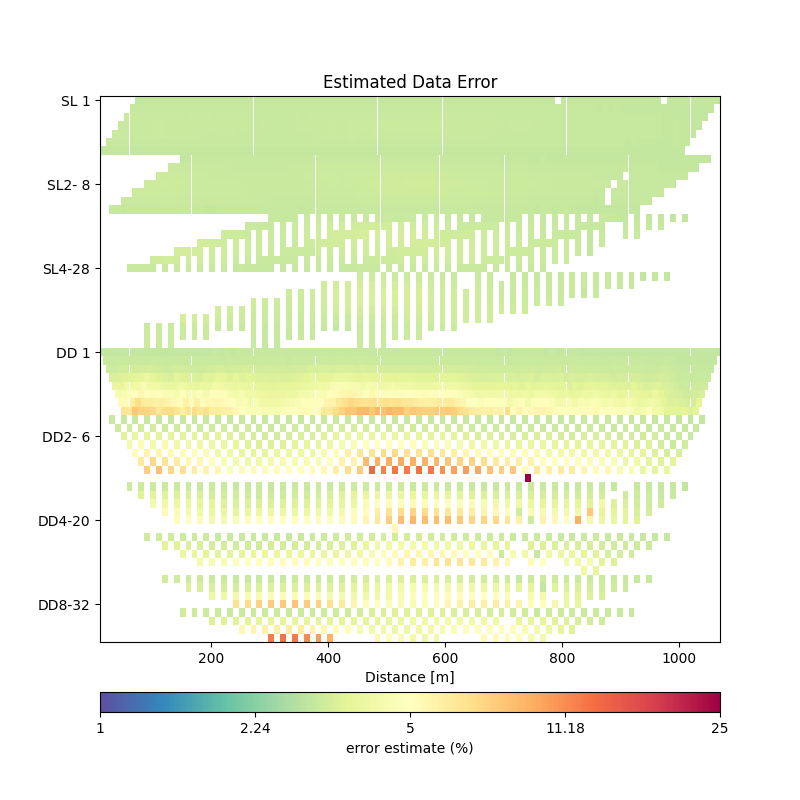

In [7]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=1, cMax=25)

ax.set_title('Estimated Data Error');

We plot the inversion result using a defined color scale.
Additionally, we plot the measured line on top of it and see that generally
there is a change from conductive overburden to resistive bedrock.




In [8]:
def onclick(event):
    # make sure click is inside the correct axes
    if event.inaxes != ax:
        return

    if event.xdata is not None and event.ydata is not None:
        x_line.append(event.xdata)
        z_line.append(event.ydata)

        ax.plot(event.xdata, event.ydata, 'bo', markersize=5)  # plot on SAME axes
        fig.canvas.draw_idle()

        print(f"Picked point: x={event.xdata:.2f}, z={event.ydata:.2f}")


10/02/26 - 13:57:48 - pyGIMLi - INFO - Found 2 regions.
10/02/26 - 13:57:48 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
10/02/26 - 13:57:48 - pyGIMLi - INFO - Found 2 regions.
10/02/26 - 13:57:48 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
10/02/26 - 13:57:48 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/02/26 - 13:57:48 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/02/26 - 13:57:48 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 4208 Cells: 7900 Boundaries: 6182
10/02/26 - 13:57:48 - pyGIMLi - INFO - Use median(data values)=480.7516
10/02/26 - 13:57:48 - pyGIMLi - INFO - Created startmodel from forward operator:1549, min/max=480.751600/480.751600
10/02/26 - 13:57:48 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001BA00B7F010>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 8.26/2.7e+04
min/max (error): 3%/3%
min/max (start model): 481/481
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  370.91
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   95.86 (dPhi = 73.69%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   53.93 (dPhi = 43.13%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   35.08 (dPhi = 34.38%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   32.28 (dPhi = 7.68%) lam: 20.0

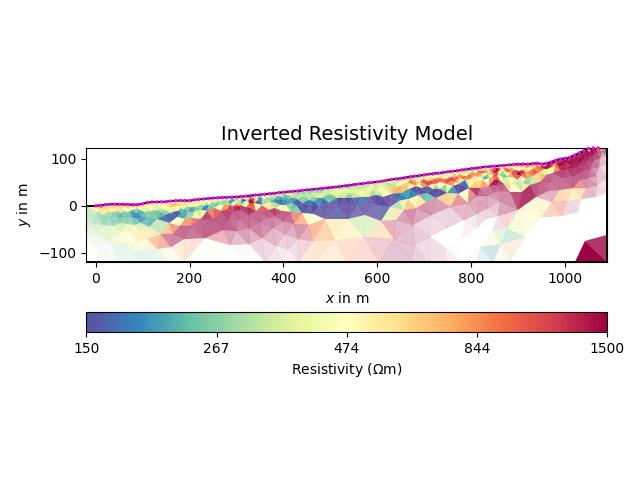

In [9]:
# lists to store clicked points
x_line = []
z_line = []

data.estimateError()
mgr = ert.Manager(data)
mgr.invert(paraDepth=120, zWeight=0.5, verbose=True)

ax, cb = mgr.showResult(cMin=150, cMax=1500)  # plot the inverted resistivity model

ax.set_title('Inverted Resistivity Model', fontsize=14)

fig = ax.figure  

# connect click handler to the SAME figure
cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()


In [11]:
fig.canvas.mpl_disconnect(cid)

plt.ion()

print(x_line)
print(z_line)

[109.7057273411107, 128.87678680999707, 156.56831715394432, 177.86949434159604, 192.78031837295222, 207.69114240430847, 237.51279046702084, 246.03326134208154, 273.72479168602877, 314.197028342567, 354.6692649991053, 393.01138393687836, 424.963149718356, 459.04503321859875, 501.6473875939022, 518.6883293440236, 574.071390031918, 608.1532735321608, 629.4544507198125, 659.2760987825249, 691.2278645640025, 727.4398657830104, 759.391631564488, 782.8229264709049, 799.8638682210262, 833.9457517212691, 850.9866934713905, 870.1577529402769, 895.719165565459, 927.6709313469366, 957.4925794096489, 972.4034034410051]
[-64.8300888640905, -46.78585814866153, -36.13526955483576, -29.744916398540227, -16.964210085949162, -21.224445523479517, -12.703974648418807, -6.313621492123275, -4.1835037733580975, 4.336967101702612, -4.1835037733580975, -6.313621492123275, -14.834092367183985, -25.48468096100987, -34.00515183607058, -63.82679989878295, -72.3472707738436, -61.696682180017774, -19.09432780471434, 

We now want to include this line into the inversion mesh.
Therefore we generate the geometry of the inversion, a polygone from the line
and merge both objects before we send it to the mesh generation.

For line = mt.createPolygon...
- if 1: boundary contraint
- if >1: internal structure (bedrock)
- to clip for fault:
    xmin, xmax = 0, 200
    xz_clip = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
    line = mt.createPolygon(xz_clip, marker=2)


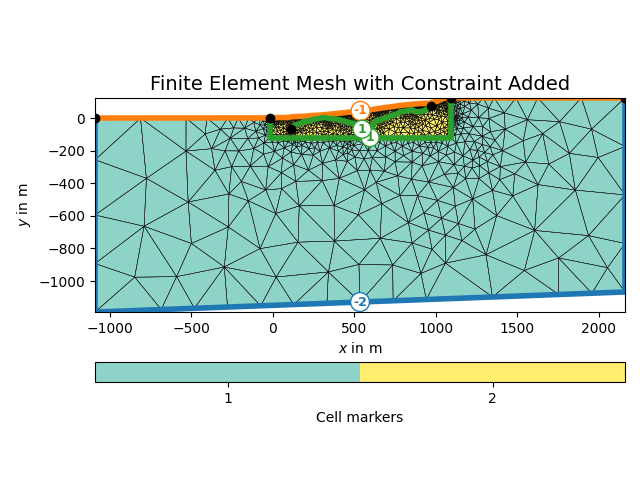

In [12]:
xz = np.column_stack([x_line, z_line])

# make sure line in domain
xmin, xmax = data.sensorPositions()[:,0].min(), data.sensorPositions()[:,0].max()
xz = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
xz[:, 1] -= 0.5  # ensure not to hit the surface

# build a piecewise linear complex (PLC) for meshing based on electrode pos
plc = mt.createParaMeshPLC(data, paraDepth=120, boundary=1)

# turn the xz points into polyline from topography or structure
line = mt.createPolygon(xz, marker=2)

plc += line

# generates the finite element mesh
mesh = mt.createMesh(plc, quality=34.6)  

ax, _ = pg.show(mesh, markers=True, showMesh=True)
ax.set_title('Finite Element Mesh with Constraint Added', fontsize=14);


We see the outer boundaries have markers of -1 (homogeneous Neumann, no-flow)
and -2 (mixed) important to define the boundary conditions of the forward
problem. The interface between the inversion domain (yellow) and the outer
region (blue) and the added interface are >0 and do not affect the forward.
We now use the generated mesh in a new ERT manager by setting it.




10/02/26 - 14:00:24 - pyGIMLi - INFO - Found 2 regions.
10/02/26 - 14:00:24 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
10/02/26 - 14:00:24 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/02/26 - 14:00:24 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/02/26 - 14:00:24 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 6747 Cells: 12968 Boundaries: 9988
10/02/26 - 14:00:24 - pyGIMLi - INFO - Use median(data values)=480.7516
10/02/26 - 14:00:24 - pyGIMLi - INFO - Created startmodel from forward operator:2564, min/max=480.751600/480.751600
10/02/26 - 14:00:24 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001BA7F2F5FD0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 8.26/2.7e+04
min/max (error): 3%/3%
min/max (start model): 481/481
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  370.76
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   96.76 (dPhi = 73.45%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   53.55 (dPhi = 43.89%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   33.41 (dPhi = 36.74%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   29.77 (dPhi = 12.41%) lam: 20.0
----------------------------------------------------

Text(0.5, 1.0, 'Re-Inverted Resistivity Model with Constraint Added')

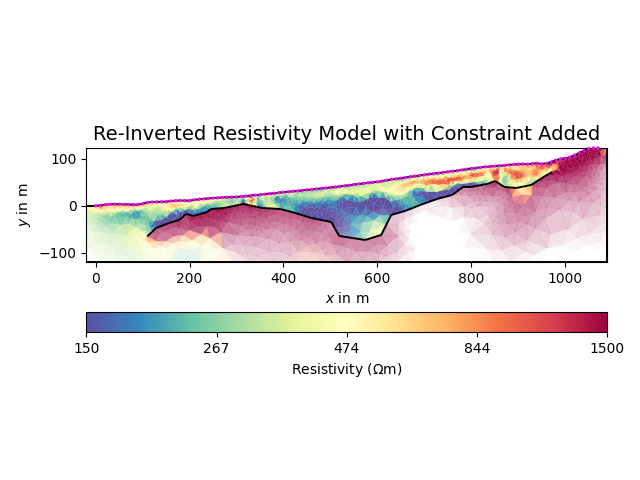

In [13]:
mgr = ert.Manager(data)
mgr.setMesh(mesh)
mgr.invert(verbose=True)
ax, cb = mgr.showResult(cMin=150, cMax=1500)

ax.set_title('Re-Inverted Resistivity Model with Constraint Added', fontsize=14)
